In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [153]:
df = pd.read_csv('2-multiplegradesdataset.csv')

In [154]:
df

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
0,4.7,7.3,82.9,3.3,80.7
1,3.8,6.6,87.9,3.3,76.0
2,5.0,6.3,88.3,2.3,89.1
3,6.3,7.6,86.0,3.2,95.9
4,3.6,8.0,89.2,3.3,70.5
5,3.6,7.9,92.0,2.3,77.9
6,6.4,6.2,99.4,4.9,89.5
7,5.2,6.7,90.9,3.5,85.1
8,3.3,7.3,91.3,1.8,82.8
9,4.8,8.0,89.6,3.7,100.0


In [155]:
df.describe()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
count,50.00000,50.000000,50.000000,50.00000,50.00000
mean,3.66800,7.022000,89.736000,3.09000,76.07000
std,1.40123,0.874419,4.924813,0.89699,11.70915
min,1.10000,4.400000,80.400000,1.50000,56.90000
25%,2.67500,6.500000,85.625000,2.22500,68.07500
50%,3.60000,7.050000,90.100000,3.20000,73.55000
75%,4.50000,7.575000,92.550000,3.57500,84.17500
max,6.80000,8.600000,100.000000,5.70000,100.00000


In [156]:
df.isnull().sum()

Study Hours           0
Sleep Hours           0
Attendance Rate       0
Social Media Hours    0
Exam Score            0
dtype: int64

In [157]:
# null data yok!!1

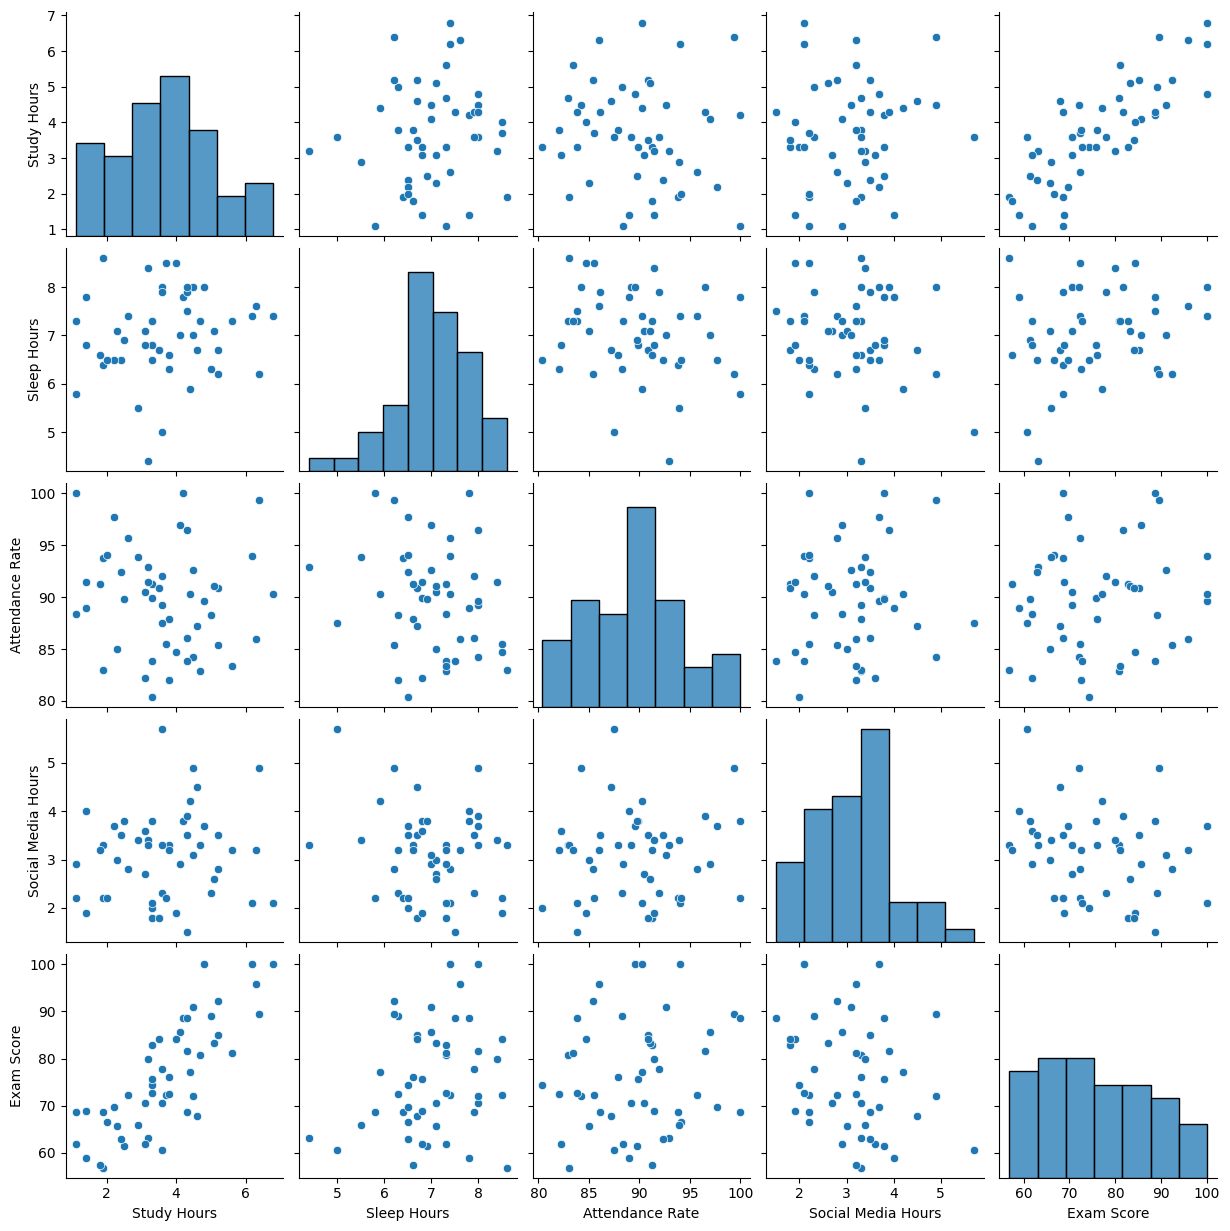

In [158]:
sns.pairplot(df) # -> tüm sayısal sütunlar arasındaki ilişkileri görselleştiren çok güçlü bir araçtır.
plt.show()

# Burada feature'ların birbirleri ile olan ilişkilerini kolerasyonunu inceliyoruz. Bu EDA gerekli çünkü birbirleriyle ilişkisi olan feature'ları
# regresyon içine sokmak garip sonuçlara sebebiyet verirdi.
# İndependent feature'larımızın birbirleri ile yüksek kolerasyona sahip olması iyi bir şey değildir !!!!!

In [159]:
df.corr() # bu şekilde de kolerasyona bakabiliyorduk !!!

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
Study Hours,1.000000,0.114015,-0.112860,0.115023,0.804266
Sleep Hours,0.114015,1.000000,-0.222024,-0.177166,0.227694
Attendance Rate,-0.112860,-0.222024,1.000000,0.068272,0.123791
Social Media Hours,0.115023,-0.177166,0.068272,1.000000,-0.248743
Exam Score,0.804266,0.227694,0.123791,-0.248743,1.000000


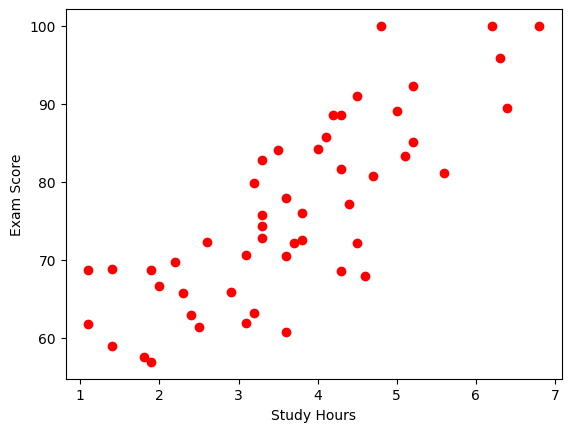

In [160]:
plt.scatter(x=df['Study Hours'], y=df["Exam Score"], color = "r")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show() # plt.pairplot -> eğer çok fazla kolon varsa bu şekilde yaparak tek tek inceleyebiliriz.

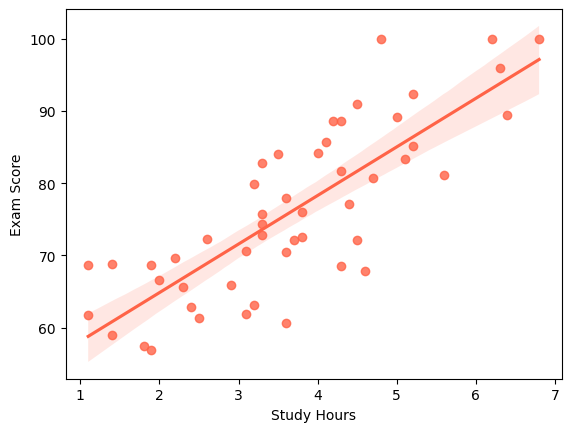

In [161]:
sns.regplot(x=df["Study Hours"], y=df["Exam Score"], color="tomato")
plt.show()
# seaborndaki regplot fonksiyonu regresyon için best fit line çiziyor...

In [162]:
df.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
0,4.7,7.3,82.9,3.3,80.7
1,3.8,6.6,87.9,3.3,76.0
2,5.0,6.3,88.3,2.3,89.1
3,6.3,7.6,86.0,3.2,95.9
4,3.6,8.0,89.2,3.3,70.5


In [163]:
# independent and dependent features 

X = df.iloc[:,:-1] # --> Son sütun hariç diğerlerini al.
y = df.iloc[:,-1] # --> Sadece son sütunu al.

# Bunu yapabilmek için dependent feature son kolonda olmalı!!!!

# X = df[['Study Hours', 'Sleep Hours', 'Attendance Rate', 'Social Media Hours']]
# y= df['Exam Score']

In [164]:
X

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours
0,4.7,7.3,82.9,3.3
1,3.8,6.6,87.9,3.3
2,5.0,6.3,88.3,2.3
3,6.3,7.6,86.0,3.2
4,3.6,8.0,89.2,3.3
5,3.6,7.9,92.0,2.3
6,6.4,6.2,99.4,4.9
7,5.2,6.7,90.9,3.5
8,3.3,7.3,91.3,1.8
9,4.8,8.0,89.6,3.7


In [165]:
y

0      80.7
1      76.0
2      89.1
3      95.9
4      70.5
5      77.9
6      89.5
7      85.1
8      82.8
9     100.0
10     74.3
11     75.7
12     77.1
13     68.7
14     59.0
15     79.9
16     61.4
17     72.1
18     72.3
19     68.7
20    100.0
21     72.2
22     85.7
23     56.9
24     63.2
25     88.6
26     65.7
27     67.9
28     70.6
29     60.7
30     61.9
31    100.0
32     84.2
33     62.9
34     92.3
35     69.7
36     68.6
37     61.8
38     66.6
39     88.6
40     83.3
41     81.7
42     72.5
43     84.1
44     57.5
45     65.9
46     72.8
47     81.1
48     91.0
49     68.8
Name: Exam Score, dtype: float64

In [166]:
# train - test split

from sklearn.model_selection import train_test_split

In [167]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

In [168]:
from sklearn.preprocessing import StandardScaler

In [169]:
scaler = StandardScaler()

In [170]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [171]:
X_train

array([[ 7.64922342e-01,  1.07637448e+00,  2.70413080e-03,
         6.75932027e-01],
       [-1.60676425e+00, -3.94765312e-01,  3.42883785e-01,
         1.46070057e-01],
       [ 1.39737210e+00,  3.40804586e-01, -1.23795108e+00,
         1.46070057e-01],
       [-1.92298913e+00, -1.84602484e-01,  3.82904921e-01,
        -1.23157107e+00],
       [ 2.11528804e-01,  2.55603439e-02,  1.48348616e+00,
        -1.71847126e-01],
       [ 2.90585024e-01,  8.66211656e-01,  2.08380319e+00,
         7.81904421e-01],
       [-2.56398550e-02, -7.10009554e-01, -1.51809903e+00,
         1.46070057e-01],
       [ 9.23034781e-01, -7.10009554e-01, -2.57433252e-01,
        -8.07681490e-01],
       [-4.20920953e-01,  3.40804586e-01, -1.15790881e+00,
        -1.01962628e+00],
       [-2.56398550e-02, -3.94765312e-01, -3.37475524e-01,
         2.52042451e-01],
       [ 3.69641243e-01,  5.50967414e-01, -1.15790881e+00,
        -1.65546064e+00],
       [-9.74314491e-01,  4.45886000e-01,  1.22334877e+00,
      

In [172]:
from sklearn.linear_model import LinearRegression

In [173]:
regression = LinearRegression()

In [174]:
regression.fit(X_train,y_train) # modeli eğittik!

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [175]:
# yeni bir öğrenci gelseydi eğer , bu yeni öğrencinin notlarını predict(tahmin) edebiliriz.

In [176]:
df.iloc[0]

Study Hours            4.7
Sleep Hours            7.3
Attendance Rate       82.9
Social Media Hours     3.3
Exam Score            80.7
Name: 0, dtype: float64

In [177]:
new_student = [[5,7,90,5]]

In [178]:
new_student_scaled = scaler.transform(new_student)

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [179]:
regression.predict(new_student_scaled) # doğruluğunu henüz hesaplamadık belki de saçma sapan bir sonuç!

array([77.9096328])

In [180]:
# prediction

In [196]:
y_pred = regression.predict(X_test)
y_pred = np.clip(y_pred, 0, 100) # tahminlerin 0 ile 100 arasında olmasını istiyoruz !!! ÖNEMLİ!

In [182]:
y_pred

array([ 67.04704385,  57.90545589,  83.63084813,  63.69399367,
        69.73079557,  80.76485587,  93.76445033,  65.93953528,
        64.58675718,  78.42296106,  56.67860558,  64.44046585,
       100.        ])

In [183]:
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score

In [184]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
print("mse: ", mse)
print("mae: ", mae)

mse:  14.078833328396794
mae:  3.0766890685526196


In [185]:
score = r2_score(y_test,y_pred)
print("score: ",score)

score:  0.9186842639173536


In [186]:
# ---> %91 oranında başarılı tahmin

In [187]:
# adjusted score
adj_r2 = 1 - ((1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

In [188]:
adj_r2

0.8780263958760304

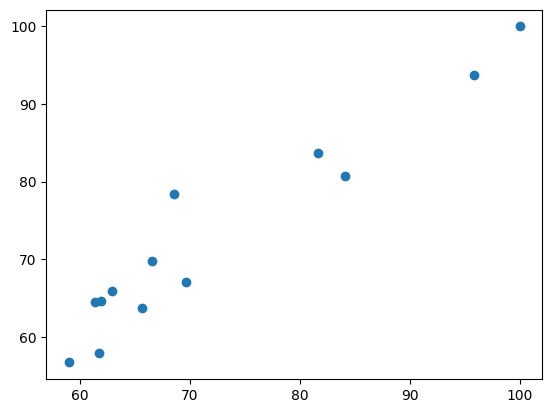

In [189]:
plt.scatter(y_test,y_pred)
plt.show()

In [190]:
residuals = y_test - y_pred

In [191]:
print(residuals)

35    2.652956
37    3.894544
41   -1.930848
26    2.006006
38   -3.130796
43    3.335144
3     2.135550
33   -3.039535
30   -2.686757
36   -9.822961
14    2.321394
16   -3.040466
20    0.000000
Name: Exam Score, dtype: float64


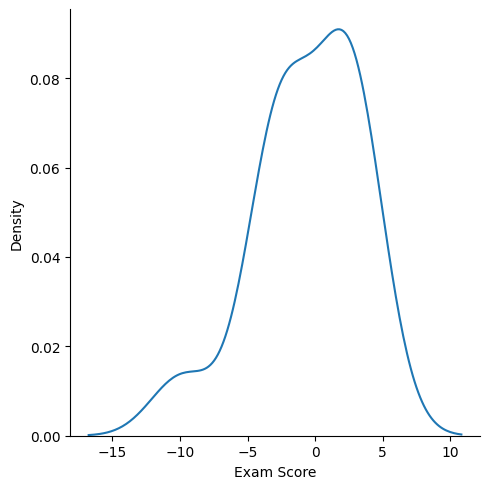

In [192]:
sns.displot(residuals, kind="kde")
plt.show()

In [193]:
regression.intercept_

np.float64(77.41081081081082)

In [194]:
regression.coef_

array([ 9.28014703,  1.78967062,  3.24340001, -4.08127695])

In [195]:
X.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours
0,4.7,7.3,82.9,3.3
1,3.8,6.6,87.9,3.3
2,5.0,6.3,88.3,2.3
3,6.3,7.6,86.0,3.2
4,3.6,8.0,89.2,3.3


In [197]:
new_student

[[5, 7, 90, 5]]

In [199]:
students = [
    [6, 8, 95, 5],
    [3, 6, 85, 4],
    [4, 7, 80, 3]
]

In [200]:
regression.predict(scaler.transform(students))

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([90.37189122, 62.43586785, 72.73292556])